---
title: "Exercise"
subtitle: "DS 2023 | Communicating with Data"
type: lesson
---


## Overview

**Metadata**

- **name:** Exercise and Pulse
- **description:** Repeated-measures pulse readings for 30 subjects, recorded at several time points under different diets and types of exercise.
- **provenance:** Stanford PSYCH 252 course teaching materials (a repeated-measures / split-plot ANOVA example), redistributed via seaborn-data. No formal publication.
- **format:** long / tidy — 90 rows x 6 columns.

**Data dictionary**

- `Unnamed: 0` — *(identifier)* original row number from the source file.
- `id` — *(identifier)* subject id (30 subjects).
- `diet` — *(identifier)* `low fat` or `no fat`.
- `pulse` — *(measurement)* heart rate in beats per minute.
- `time` — *(identifier)* time point (`1 min`, `15 min`, `30 min`).
- `kind` — *(identifier)* activity: `rest`, `walking`, or `running`.

**Structure**

- **Rows:** 90 — subjects x time points.
- **Columns:** 6.
- **Identifiers:** `id`, `diet`, `time`, `kind`.
- **Measurements:** `pulse`.

**Use cases**

- repeated-measures line plots over time
- grouped aggregation by diet and activity
- interaction plots


In [122]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML

### Long form (tidy)

In [123]:
exercise = sns.load_dataset('exercise')
exercise.info()
exercise

<class 'pandas.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   Unnamed: 0  90 non-null     int64   
 1   id          90 non-null     int64   
 2   diet        90 non-null     category
 3   pulse       90 non-null     int64   
 4   time        90 non-null     category
 5   kind        90 non-null     category
dtypes: category(3), int64(3)
memory usage: 2.9 KB


,Unnamed: 0,id,diet,pulse,time,kind
0,0,1,low fat,85,1 min,rest
1,1,1,low fat,85,15 min,rest
2,2,1,low fat,88,30 min,rest
3,3,2,low fat,90,1 min,rest
4,4,2,low fat,92,15 min,rest
...,...,...,...,...,...,...
85,85,29,no fat,135,15 min,running
86,86,29,no fat,130,30 min,running
87,87,30,no fat,99,1 min,running
88,88,30,no fat,111,15 min,running


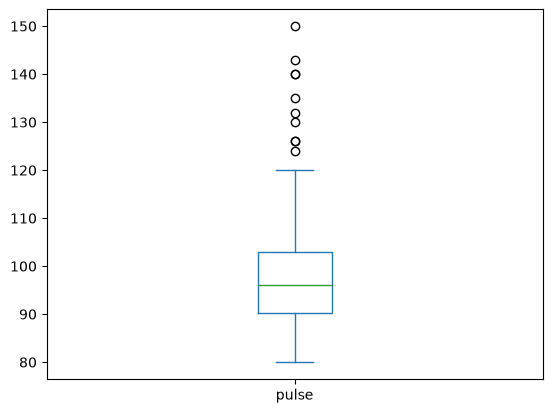

In [57]:
exercise.pulse.plot.box()
plt.show()

### Exploring structure

Each subject is associated with one value of `kind` and one value of `diet`.

In [155]:
exercise[exercise['id'] == 7]

,Unnamed: 0,id,diet,pulse,time,kind,cohort_member
18,18,7,no fat,87,1 min,rest,4
19,19,7,no fat,88,15 min,rest,5
20,20,7,no fat,90,30 min,rest,6


These means the test population is divided into $6$ groups, since there are $3$ values of `kind` and $2$ values of `diet` and $2 \times 3 = 6$.

### Long form with key index

In [357]:
exercise1 = exercise.set_index(['id','diet','kind','time'])[['pulse']]
print(exercise1.index.has_duplicates)
exercise1

False


pulse
id diet    kind    time         
1  low fat rest    1 min      85
                   15 min     85
                   30 min     88
2  low fat rest    1 min      90
                   15 min     92
...                          ...
29 no fat  running 15 min    135
                   30 min    130
30 no fat  running 1 min      99
                   15 min    111
                   30 min    150

[90 rows x 1 columns]

### Wide form with key index

In [363]:
exercise2 = exercise1.pulse.unstack()
exercise2

,,time,1 min,15 min,30 min
id,diet,kind,,,
1,low fat,rest,85,85,88
2,low fat,rest,90,92,93
3,low fat,rest,97,97,94
4,low fat,rest,80,82,83
5,low fat,rest,91,92,91
6,no fat,rest,83,83,84
7,no fat,rest,87,88,90
8,no fat,rest,92,94,95
9,no fat,rest,97,99,96


### Wide form aggregated

In [412]:
exercise3 = exercise2.groupby(['diet','kind']).mean()
exercise3

time             1 min  15 min  30 min
diet    kind                          
no fat  rest      91.8    92.2    93.0
        walking   95.6    98.6    96.6
        running   98.2   124.4   140.6
low fat rest      88.6    89.6    89.8
        walking   90.6    94.6    95.2
        running   94.0   109.8   111.4

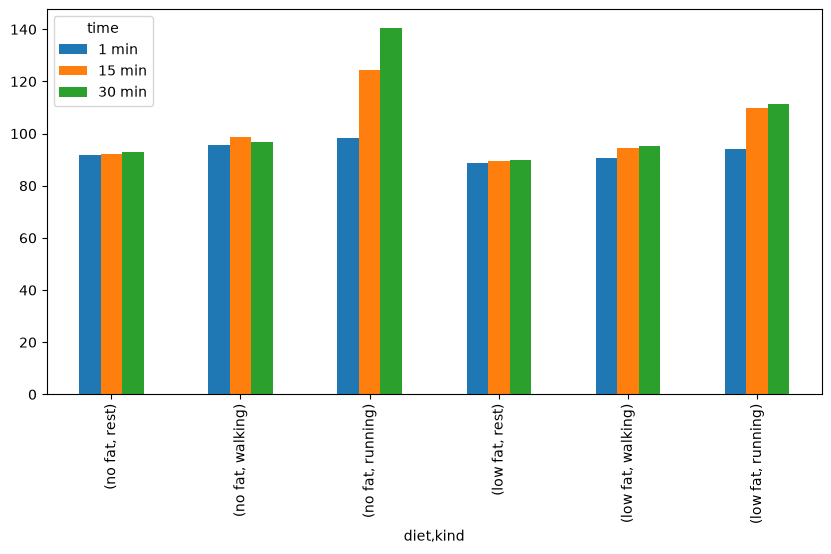

In [410]:
exercise3.plot.bar(figsize=(10,5))
plt.show()

### Wide form double aggregated

In [423]:
exercise4 = exercise3.mean(axis=1).unstack()
exercise4

kind,rest,walking,running
diet,,,
no fat,92.333333,96.933333,121.066667
low fat,89.333333,93.466667,105.066667


In [419]:
exercise4.style.format(precision=2).background_gradient(axis=None, cmap='Reds')

kind,rest,walking,running
diet,,,
no fat,92.33,96.93,121.07
low fat,89.33,93.47,105.07


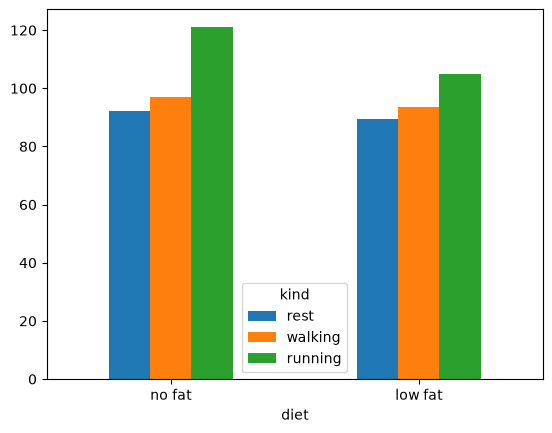

In [426]:
exercise4.plot.bar(rot=0)
plt.show()

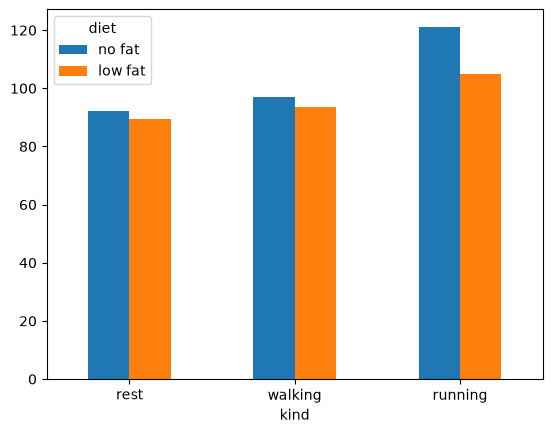

In [430]:
exercise4.T.plot.bar(rot=0)
plt.show()

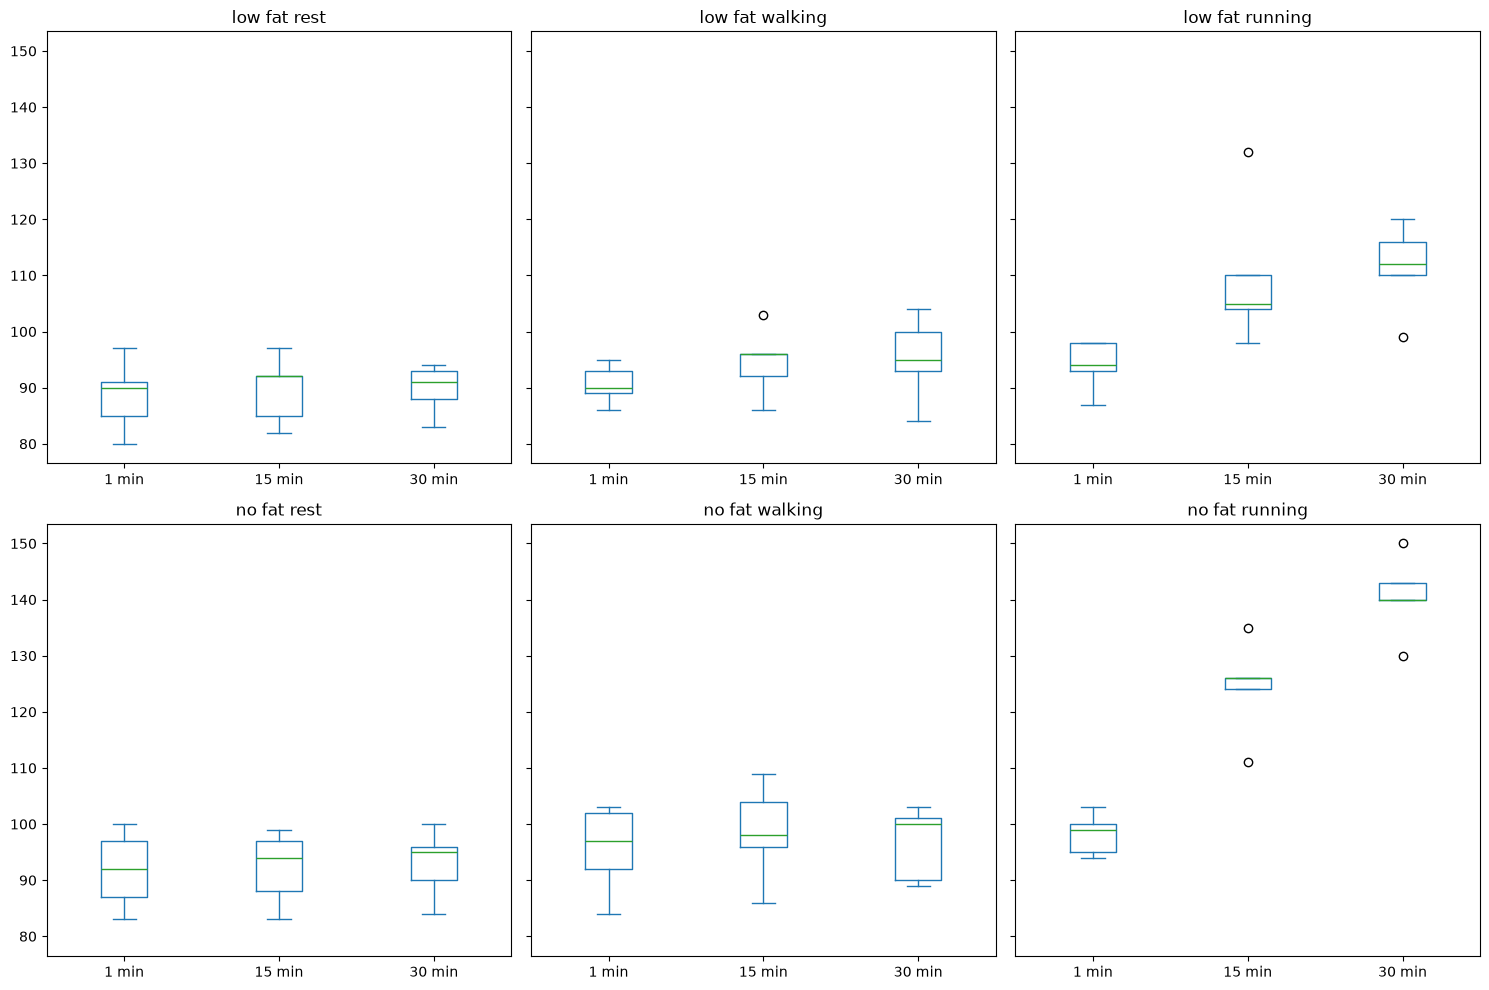

In [431]:
row_vals = exercise2.reset_index()['diet'].unique().tolist() # 2 values
col_vals = exercise2.reset_index()['kind'].unique().tolist() # 3 values
fig, ax = plt.subplots(len(row_vals), len(col_vals), figsize=(len(col_vals) * 5, len(row_vals) * 5), sharey=True)
for i, g in enumerate(exercise2.groupby(['diet','kind'])):
    idx, df = g
    row_num = row_vals.index(df.reset_index().diet.values[0])
    col_num = col_vals.index(df.reset_index().kind.values[0])
    df.plot.box(title=" ".join(idx), ax=ax[row_num, col_num])
plt.tight_layout()
plt.show()

In [428]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Fit a Two-Way ANOVA model to test the interaction between the type of exercise and time spent exercising
model = ols('pulse ~ C(kind) + C(time) + C(kind):C(time)', data=exercise).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
anova_table

,sum_sq,df,F,PR(>F)
C(kind),8326.066667,2.0,51.616541,3.517667e-15
C(time),2066.600000,2.0,12.811661,1.464296e-05
C(kind):C(time),2723.333333,4.0,8.441504,9.601173e-06
Residual,6532.900000,81.0,NaN,NaN
